# 🏆 Platform Scoring Application
### Unified HR Candidate Evaluation Across LinkedIn, GitHub, LeetCode, HackerRank & StackOverflow
---
This notebook computes **platform-level scores** from sub-metric scores and then combines them into a single **Overall Platform Score** using configurable platform weights.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#cbd5e1',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})

PLATFORM_COLORS = {
    'LinkedIn':       '#0077B5',
    'GitHub':         '#6e40c9',
    'LeetCode':       '#FFA116',
    'HackerRank':     '#2EC866',
    'StackOverflow':  '#F48024',
}

print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


## 2. Load Raw CSV Data
> If a platform CSV is unavailable (file missing / candidate not on that platform), set its variable to `None`. The scoring engine will **automatically exclude** it and **redistribute its weight** across the remaining platforms.

In [2]:
import os

DATA_DIR = "./"   # ← change to your folder containing the CSV files

PLATFORM_FILES = {
    'LinkedIn':      DATA_DIR + 'linkedin_scores.csv',
    'GitHub':        DATA_DIR + 'github_scores.csv',
    'LeetCode':      DATA_DIR + 'leetcode_scores.csv',
    'HackerRank':    DATA_DIR + 'hackerrank_scores.csv',
    'StackOverflow': DATA_DIR + 'stackoverflow_scores.csv',
}

# Load each platform — missing files produce None (not an error)
platform_raw_data = {}
for platform, filepath in PLATFORM_FILES.items():
    if os.path.exists(filepath):
        try:
            df = pd.read_csv(filepath)
            if df.empty:
                raise ValueError('Empty CSV')
            platform_raw_data[platform] = df
            print(f'  ✅  {platform:<15s} → loaded  ({len(df.columns)} columns)')
        except Exception as e:
            platform_raw_data[platform] = None
            print(f'  ⚠️  {platform:<15s} → load ERROR: {e}  (will be excluded)')
    else:
        platform_raw_data[platform] = None
        print(f'  ❌  {platform:<15s} → file NOT FOUND  (will be excluded)')

available   = [p for p, d in platform_raw_data.items() if d is not None]
unavailable = [p for p, d in platform_raw_data.items() if d is None]
print(f'\n📂 Available   : {available}')
print(f'🚫 Unavailable : {unavailable if unavailable else "None — all platforms present"}')

  ✅  LinkedIn        → loaded  (20 columns)
  ✅  GitHub          → loaded  (18 columns)
  ✅  LeetCode        → loaded  (16 columns)
  ✅  HackerRank      → loaded  (13 columns)
  ✅  StackOverflow   → loaded  (15 columns)

📂 Available   : ['LinkedIn', 'GitHub', 'LeetCode', 'HackerRank', 'StackOverflow']
🚫 Unavailable : None — all platforms present


## 3. Sub-Metric Weightage Configuration
> Edit the weight dictionaries below to adjust how each sub-metric contributes to its platform score. All weights within a platform must sum to **1.0 (100%)**.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  LINKEDIN  (user-defined weights)
# ══════════════════════════════════════════════════════════════════════════════
LINKEDIN_WEIGHTS = {
    'employment_consistency_score':    0.20,  # Employment Consistency
    'career_progression_trajectory':   0.18,  # Career Progression Trajectory
    'company_prestige_score':          0.12,  # Company Prestige Score
    'skill_endorsement_credibility':   0.10,  # Skill Endorsement Credibility
    'recommendation_authenticity':     0.10,  # Recommendation Authenticity
    'profile_completeness':            0.08,  # Profile Completeness
    'network_size_quality':            0.08,  # Network Quality
    'education_verification_score':    0.07,  # Education Verification
    'activity_frequency_score':        0.04,  # Activity Frequency
    'content_quality_score':           0.03,  # Content Quality
}

# ══════════════════════════════════════════════════════════════════════════════
#  GITHUB  (user-defined weights)
# ══════════════════════════════════════════════════════════════════════════════
GITHUB_WEIGHTS = {
    'repository_originality':           0.22,  # Repository Quality Score
    'commit_frequency_score':           0.20,  # Commit Frequency & Consistency
    'contribution_graph_density_score': 0.15,  # Pull Request Acceptance Rate (mapped)
    'project_longevity':                0.12,  # Project Longevity
    'stars_received_score':             0.07,  # Stars Received
    'forks_received_score':             0.03,  # Forks Received
    'documentation_quality':            0.06,  # CI/CD & Documentation Quality
    'ci_cd_usage':                      0.02,  # CI/CD Usage
    'language_diversity':               0.06,  # Language Diversity
    'collaboration_network':            0.05,  # Code Review Activity
    'repository_count_score':           0.02,  # Contribution Graph Density
}

# ══════════════════════════════════════════════════════════════════════════════
#  LEETCODE  (assigned weights)
# ══════════════════════════════════════════════════════════════════════════════
LEETCODE_WEIGHTS = {
    'problems_solved_score':       0.25,  # Volume of problems solved
    'global_ranking_score':        0.20,  # Global ranking position
    'top_percentage_score':        0.15,  # Top % ranking
    'contest_rating_score':        0.12,  # Contest rating
    'contest_participation_score': 0.08,  # Contest participation
    'acceptance_rate_score':       0.10,  # Acceptance rate
    'difficulty_distribution':     0.05,  # Hard/Medium/Easy mix
    'language_diversity':          0.03,  # Multi-language usage
    'category_coverage':           0.02,  # Topic category breadth
}

# ══════════════════════════════════════════════════════════════════════════════
#  HACKERRANK  (assigned weights)
# ══════════════════════════════════════════════════════════════════════════════
HACKERRANK_WEIGHTS = {
    'skill_certificates_score':  0.30,  # Skill certificates earned
    'avg_stars_score':           0.25,  # Average stars across domains
    'domain_score_quality':      0.20,  # Quality of domain scores
    'leaderboard_rank_score':    0.15,  # Leaderboard ranking
    'badge_portfolio_quality':   0.10,  # Badge portfolio breadth
}

# ══════════════════════════════════════════════════════════════════════════════
#  STACKOVERFLOW  (assigned weights)
# ══════════════════════════════════════════════════════════════════════════════
STACKOVERFLOW_WEIGHTS = {
    'reputation_score':        0.30,  # Reputation points
    'acceptance_score':        0.20,  # Answer acceptance rate
    'answer_count_score':      0.18,  # Volume of answers
    'badge_portfolio_score':   0.15,  # Badge portfolio
    'vote_ratio_score':        0.10,  # Up/down vote ratio
    'question_count_score':    0.05,  # Questions asked
    'account_age_score':       0.02,  # Account seniority
}

# ══════════════════════════════════════════════════════════════════════════════
#  OVERALL PLATFORM WEIGHTS  (how much each platform contributes to final score)
# ══════════════════════════════════════════════════════════════════════════════
OVERALL_PLATFORM_WEIGHTS = {
    'LinkedIn':      0.30,
    'GitHub':        0.30,
    'LeetCode':      0.20,
    'HackerRank':    0.12,
    'StackOverflow': 0.08,
}

# Validate weights
for name, wts in [('LinkedIn', LINKEDIN_WEIGHTS), ('GitHub', GITHUB_WEIGHTS),
                   ('LeetCode', LEETCODE_WEIGHTS), ('HackerRank', HACKERRANK_WEIGHTS),
                   ('StackOverflow', STACKOVERFLOW_WEIGHTS),
                   ('Overall', OVERALL_PLATFORM_WEIGHTS)]:
    total = round(sum(wts.values()), 4)
    status = '✅' if total == 1.0 else '⚠️  MISMATCH'
    print(f"{status}  {name:15s} → weights sum = {total}")

✅  LinkedIn        → weights sum = 1.0
✅  GitHub          → weights sum = 1.0
✅  LeetCode        → weights sum = 1.0
✅  HackerRank      → weights sum = 1.0
✅  StackOverflow   → weights sum = 1.0
✅  Overall         → weights sum = 1.0


## 4. Score Computation Engine

In [4]:
def clamp(value, lo=0, hi=100):
    """Clamp a score to [lo, hi]. Sentinel values (-1) are treated as 0."""
    if pd.isna(value) or value < 0:
        return 0.0
    return float(np.clip(value, lo, hi))


def weighted_platform_score(row: pd.Series, weights: dict, label: str) -> dict:
    """
    Compute a weighted platform score from a single-row DataFrame.
    Missing columns are silently skipped and weights are renormalised.

    Returns
    -------
    dict with keys:
        platform_score  – final 0-100 score
        breakdown       – per-sub-metric contribution dict
        warnings        – list of skipped columns
    """
    present_weights = {col: w for col, w in weights.items() if col in row.index}
    missing         = [col for col in weights if col not in row.index]

    if not present_weights:
        return {'platform_score': 0.0, 'breakdown': {}, 'warnings': missing}

    total_weight = sum(present_weights.values())
    breakdown = {}
    weighted_sum = 0.0

    for col, raw_weight in present_weights.items():
        norm_weight   = raw_weight / total_weight       # renormalise if cols missing
        sub_score     = clamp(row[col])
        contribution  = sub_score * norm_weight
        weighted_sum += contribution
        breakdown[col] = {
            'raw_score':    round(sub_score, 2),
            'weight':       round(norm_weight * 100, 2),
            'contribution': round(contribution, 2),
        }

    return {
        'platform_score': round(weighted_sum, 2),
        'breakdown':      breakdown,
        'warnings':       missing,
    }


# ── Grade mapping ─────────────────────────────────────────────────────────────
def score_to_grade(s):
    if s >= 850: return 'A+', '🟢 Excellent'
    if s >= 750: return 'A',  '🟢 Very Good'
    if s >= 650: return 'B+', '🟡 Good'
    if s >= 550: return 'B',  '🟡 Above Average'
    if s >= 450: return 'C+', '🟠 Average'
    if s >= 350: return 'C',  '🟠 Below Average'
    return 'D', '🔴 Needs Improvement'

print('✅ Scoring engine ready.')

✅ Scoring engine ready.


## 5. Compute Individual Platform Scores

In [5]:
# Map each platform to its weight config
PLATFORM_WEIGHT_MAP = {
    'LinkedIn':      LINKEDIN_WEIGHTS,
    'GitHub':        GITHUB_WEIGHTS,
    'LeetCode':      LEETCODE_WEIGHTS,
    'HackerRank':    HACKERRANK_WEIGHTS,
    'StackOverflow': STACKOVERFLOW_WEIGHTS,
}

# Compute scores only for available platforms
platform_results = {}
platform_scores  = {}

for platform, raw_df in platform_raw_data.items():
    if raw_df is not None:
        result = weighted_platform_score(
            raw_df.iloc[0],
            PLATFORM_WEIGHT_MAP[platform],
            platform
        )
        platform_results[platform] = result
        platform_scores[platform]  = result['platform_score']
    else:
        platform_results[platform] = None
        platform_scores[platform]  = None   # explicitly None = missing

print('\n📊 Platform Scores (0–100)\n' + '─'*40)
for plat, score in platform_scores.items():
    if score is not None:
        bar = '█' * int(score / 5)
        print(f"  ✅  {plat:<15s} {score:5.1f}  {bar}")
    else:
        print(f"  ❌  {plat:<15s}  N/A  (platform data unavailable)")


📊 Platform Scores (0–100)
────────────────────────────────────────
  ✅  LinkedIn         69.9  █████████████
  ✅  GitHub           46.5  █████████
  ✅  LeetCode         37.8  ███████
  ✅  HackerRank       30.6  ██████
  ✅  StackOverflow     1.9  


## 6. Compute Overall Platform Score
> **Weight Adjustment Rule:** If a platform's data is missing (`None`), its configured weight is removed from the pool and the remaining platform weights are **proportionally scaled up** so they always sum to 100%. The final score is therefore always comparable regardless of how many platforms are available.

In [6]:
# ── Dynamic weight redistribution ──────────────────────────────────────────────
# Step 1: Separate present vs absent platforms
present_platforms = {p: s for p, s in platform_scores.items() if s is not None}
absent_platforms  = {p: s for p, s in platform_scores.items() if s is None}

# Step 2: Sum of weights for PRESENT platforms only
present_weight_sum = sum(OVERALL_PLATFORM_WEIGHTS[p] for p in present_platforms)

# Step 3: Adjusted (normalised) weights — absent platforms get 0
adjusted_weights = {}
for platform in OVERALL_PLATFORM_WEIGHTS:
    if platform in present_platforms:
        adjusted_weights[platform] = OVERALL_PLATFORM_WEIGHTS[platform] / present_weight_sum
    else:
        adjusted_weights[platform] = 0.0

# Step 4: Compute overall score using adjusted weights (Scaled to 1000)
overall_score = round(
    sum(present_platforms[p] * adjusted_weights[p] * 10 for p in present_platforms), 2
)

# No need to multiply by 10 here anymore since overall_score is already out of 1000
grade, lbl = score_to_grade(overall_score)

# ── Report ─────────────────────────────────────────────────────────────────────
print('\n' + '═'*62)
print(f'  🏅  OVERALL PLATFORM SCORE  :  {overall_score}/1000')
print(f'  📋  Grade                   :  {grade}  {lbl}')
if absent_platforms:
    print(f'  ⚠️   Missing platforms       :  {", ".join(absent_platforms.keys())}')
    print(f'       → Their weights redistributed to present platforms.')
print('═'*62)

print(f'\n  {"Platform":<15} {"Score":>6}  {"Base Wt":>8}  {"Adj Wt":>8}  {"Contrib":>9}  {"Status"}')
print('  ' + '─'*62)
for p in OVERALL_PLATFORM_WEIGHTS:
    base_w = OVERALL_PLATFORM_WEIGHTS[p]
    adj_w  = adjusted_weights[p]

    if p in present_platforms:
        # Scale individual score to 1000 for the display so the math lines up
        score_out_of_1000 = present_platforms[p] * 10
        contrib = round(score_out_of_1000 * adj_w, 2)
        score_str = f'{score_out_of_1000:>6.1f}'
        status = '✅ Present'
    else:
        contrib   = 0.0
        score_str = '   N/A'
        status = '❌ Missing'

    print(f'  {p:<15} {score_str}  {base_w*100:>7.0f}%  {adj_w*100:>7.1f}%  {contrib:>9.2f}  {status}')
print('  ' + '─'*62)
print(f'  {"TOTAL":<15} {"":>6}  {"100%":>8}  {"100.0%":>8}  {overall_score:>9.2f}')


══════════════════════════════════════════════════════════════
  🏅  OVERALL PLATFORM SCORE  :  463.12/1000
  📋  Grade                   :  C+  🟠 Average
══════════════════════════════════════════════════════════════

  Platform         Score   Base Wt    Adj Wt    Contrib  Status
  ──────────────────────────────────────────────────────────────
  LinkedIn         699.2       30%     30.0%     209.76  ✅ Present
  GitHub           464.9       30%     30.0%     139.47  ✅ Present
  LeetCode         378.1       20%     20.0%      75.62  ✅ Present
  HackerRank       306.0       12%     12.0%      36.72  ✅ Present
  StackOverflow     19.4        8%      8.0%       1.55  ✅ Present
  ──────────────────────────────────────────────────────────────
  TOTAL                       100%    100.0%     463.12


## 7. Sub-Metric Breakdown per Platform

In [7]:
def print_breakdown(result, platform_name):
    if result is None:
        print(f'\n{"─"*60}')
        print(f'  ❌  {platform_name.upper()} — DATA UNAVAILABLE (excluded from scoring)')
        return
    score  = result['platform_score']
    brkdwn = result['breakdown']
    warns  = result['warnings']
    grade, lbl = score_to_grade(score)
    adj_w = adjusted_weights.get(platform_name, 0)

    print(f'\n{"─"*60}')
    print(f'  🔷  {platform_name.upper()} PLATFORM SCORE: {score}/100  [{grade} – {lbl}]')
    print(f'      Adjusted Weight in Overall: {adj_w*100:.1f}%')
    print(f'  {"Sub-Metric":<40} {"Score":>6}  {"Wt%":>5}  {"Contrib":>7}')
    print(f'  {"─"*60}')
    for col, v in brkdwn.items():
        label = col.replace('_', ' ').title()
        print(f'  {label:<40} {v["raw_score"]:>6.1f}  {v["weight"]:>4.1f}%  {v["contribution"]:>7.2f}')
    if warns:
        print(f'  ⚠️  Skipped sub-metric columns (not in CSV): {warns}')

for platform in OVERALL_PLATFORM_WEIGHTS:
    print_breakdown(platform_results[platform], platform)


────────────────────────────────────────────────────────────
  🔷  LINKEDIN PLATFORM SCORE: 69.92/100  [D – 🔴 Needs Improvement]
      Adjusted Weight in Overall: 30.0%
  Sub-Metric                                Score    Wt%  Contrib
  ────────────────────────────────────────────────────────────
  Employment Consistency Score               67.3  20.0%    13.46
  Career Progression Trajectory              78.0  18.0%    14.04
  Company Prestige Score                     88.0  12.0%    10.56
  Skill Endorsement Credibility              68.0  10.0%     6.80
  Recommendation Authenticity                 0.0  10.0%     0.00
  Profile Completeness                       74.0   8.0%     5.92
  Network Size Quality                       82.0   8.0%     6.56
  Education Verification Score              100.0   7.0%     7.00
  Activity Frequency Score                   93.1   4.0%     3.72
  Content Quality Score                      62.0   3.0%     1.86

─────────────────────────────────────────

## 8. Visualisations

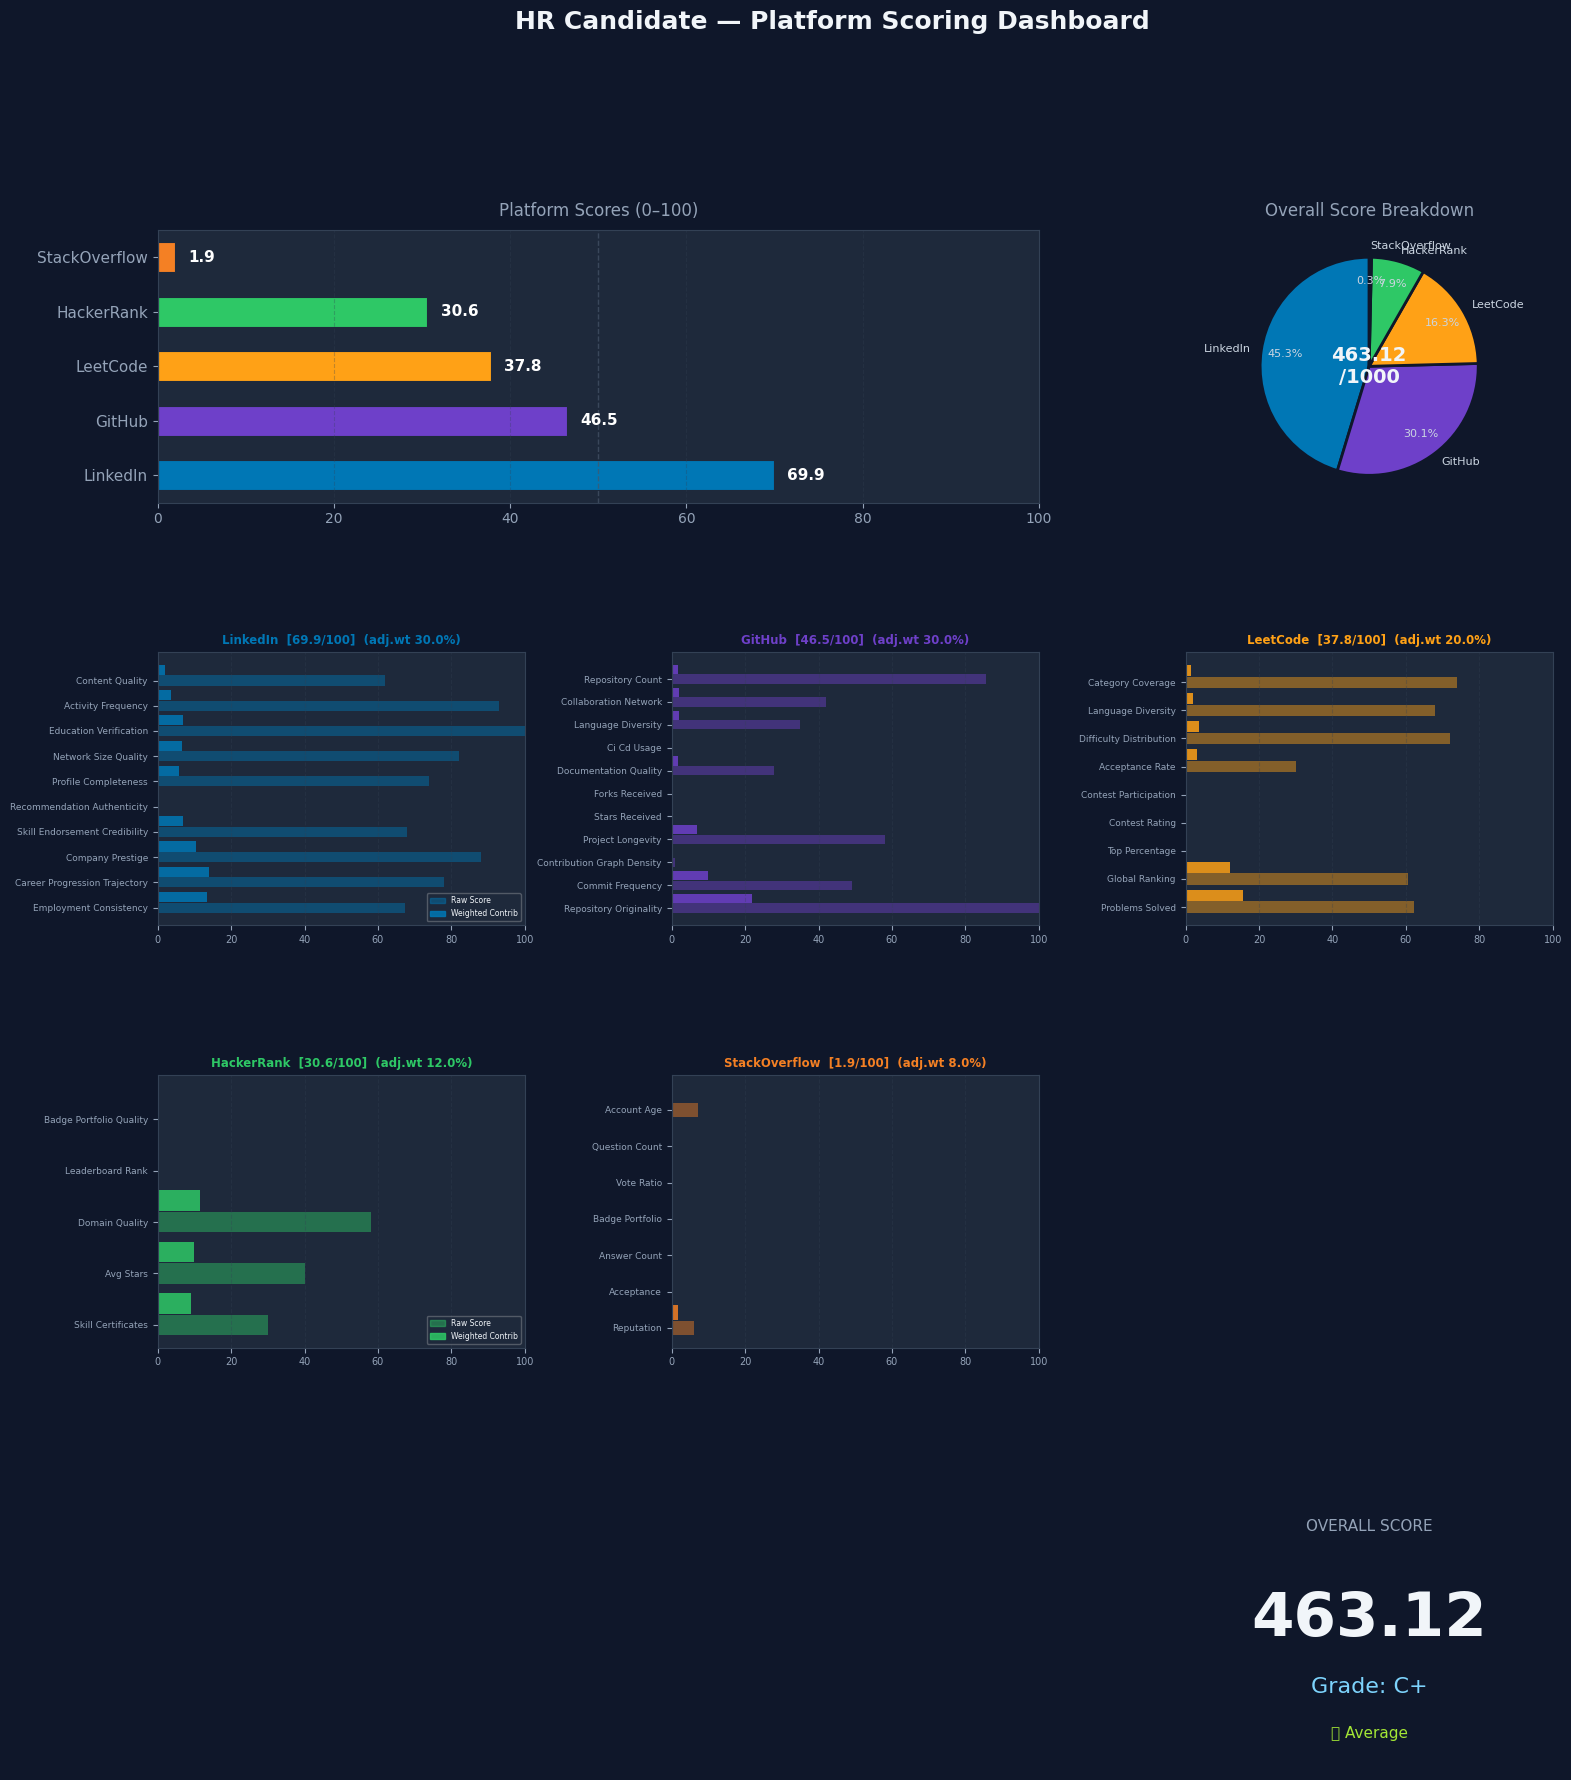

✅ Dashboard saved as platform_scoring_dashboard.png


In [8]:
# ── Only plot platforms that have data ────────────────────────────────────────
plot_platforms = [p for p in OVERALL_PLATFORM_WEIGHTS if platform_scores[p] is not None]
plot_scores    = [platform_scores[p] for p in plot_platforms]
plot_colors    = [PLATFORM_COLORS[p] for p in plot_platforms]
plot_adj_wts   = [adjusted_weights[p] for p in plot_platforms]
plot_contribs  = [round(platform_scores[p] * adjusted_weights[p], 2) for p in plot_platforms]

n_present = len(plot_platforms)
sub_rows  = (n_present + 2) // 3   # rows needed for per-platform sub-charts
total_rows = 1 + sub_rows + 1

fig = plt.figure(figsize=(18, 5 * total_rows), facecolor='#0f172a')
fig.suptitle('HR Candidate — Platform Scoring Dashboard', fontsize=18,
             fontweight='bold', color='#f1f5f9', y=0.99)
gs = GridSpec(total_rows, 3, figure=fig, hspace=0.55, wspace=0.4)

# ── 8A: Platform Scores Bar (Individual scores remain 0-100) ──────────────────
ax_gauge = fig.add_subplot(gs[0, :2])
bars = ax_gauge.barh(plot_platforms, plot_scores, color=plot_colors,
                     height=0.55, edgecolor='#1e293b', linewidth=0.8)
ax_gauge.set_xlim(0, 100)
ax_gauge.set_title('Platform Scores (0–100)', color='#94a3b8', pad=10)
ax_gauge.axvline(x=50, color='#475569', lw=1, linestyle='--', alpha=0.7)
for bar, score in zip(bars, plot_scores):
    ax_gauge.text(score + 1.5, bar.get_y() + bar.get_height()/2,
                  f'{score:.1f}', va='center', ha='left',
                  color='white', fontsize=11, fontweight='bold')
if absent_platforms:
    ax_gauge.set_xlabel(
        f'⚠️  Missing: {", ".join(absent_platforms.keys())} — weights redistributed',
        color='#f59e0b', fontsize=9
    )
ax_gauge.tick_params(axis='y', labelsize=11)
ax_gauge.grid(axis='x', alpha=0.3)
ax_gauge.set_facecolor('#1e293b')
for spine in ax_gauge.spines.values():
    spine.set_edgecolor('#334155')

# ── 8B: Donut — adjusted weight contributions ─────────────────────────────────
ax_donut = fig.add_subplot(gs[0, 2])
ax_donut.pie(plot_contribs, labels=plot_platforms, colors=plot_colors,
             autopct='%1.1f%%', startangle=90,
             textprops={'color': '#cbd5e1', 'fontsize': 8},
             wedgeprops={'edgecolor': '#0f172a', 'linewidth': 2},
             pctdistance=0.78)

# UPDATED: Changed denominator from /100 to /1000
ax_donut.text(0, 0, f'{overall_score}\n/1000', ha='center', va='center',
              fontsize=14, fontweight='bold', color='#f1f5f9')

title_suffix = ' (adjusted)' if absent_platforms else ''
ax_donut.set_title(f'Overall Score Breakdown{title_suffix}', color='#94a3b8', pad=10)
ax_donut.set_facecolor('#1e293b')

# ── 8C-8G: Per-platform sub-metric bars (present platforms only) ──────────────
sub_positions = [(1 + i // 3, i % 3) for i in range(n_present)]

for platform, (row_idx, col_idx) in zip(plot_platforms, sub_positions):
    result  = platform_results[platform]
    ax      = fig.add_subplot(gs[row_idx, col_idx])
    brkdwn  = result['breakdown']
    sub_labels   = [k.replace('_score', '').replace('_', ' ').title() for k in brkdwn]
    sub_scores   = [v['raw_score'] for v in brkdwn.values()]
    sub_contribs = [v['contribution'] for v in brkdwn.values()]
    y_pos  = range(len(sub_labels))
    color  = PLATFORM_COLORS[platform]

    ax.barh(list(y_pos), sub_scores, height=0.4, color=color,
            alpha=0.45, label='Raw Score', edgecolor='none')
    ax.barh([y + 0.42 for y in y_pos], sub_contribs, height=0.4,
            color=color, alpha=0.85, label='Weighted Contrib', edgecolor='none')

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(sub_labels, fontsize=6.5)
    ax.set_xlim(0, 100)
    ax.set_title(
        f'{platform}  [{result["platform_score"]:.1f}/100]  (adj.wt {adjusted_weights[platform]*100:.1f}%)',
        color=color, fontsize=8.5, fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.3)
    ax.set_facecolor('#1e293b')
    for spine in ax.spines.values():
        spine.set_edgecolor('#334155')
    ax.tick_params(axis='x', labelsize=7)

    if col_idx == 0:
        raw_patch = mpatches.Patch(color=color, alpha=0.45, label='Raw Score')
        wt_patch  = mpatches.Patch(color=color, alpha=0.85, label='Weighted Contrib')
        ax.legend(handles=[raw_patch, wt_patch], fontsize=5.5,
                  loc='lower right', framealpha=0.3)

# ── 8H: Overall score card ────────────────────────────────────────────────────
ax_card = fig.add_subplot(gs[total_rows - 1, 2])
ax_card.axis('off')

# Passes the new 1000-scale overall_score to your updated grading function
grade, lbl = score_to_grade(overall_score)

ax_card.text(0.5, 0.92, 'OVERALL SCORE', ha='center', va='top',
             fontsize=11, color='#94a3b8', transform=ax_card.transAxes)
ax_card.text(0.5, 0.66, f'{overall_score}', ha='center', va='top',
             fontsize=44, fontweight='bold', color='#f1f5f9',
             transform=ax_card.transAxes)
ax_card.text(0.5, 0.34, f'Grade: {grade}', ha='center', va='top',
             fontsize=16, color='#7dd3fc', transform=ax_card.transAxes)
ax_card.text(0.5, 0.16, lbl, ha='center', va='top',
             fontsize=11, color='#a3e635', transform=ax_card.transAxes)
if absent_platforms:
    ax_card.text(0.5, 0.04,
                 f'({n_present}/{len(OVERALL_PLATFORM_WEIGHTS)} platforms)',
                 ha='center', va='top', fontsize=8,
                 color='#f59e0b', transform=ax_card.transAxes)
ax_card.set_facecolor('#1e2d45')
for spine in ax_card.spines.values():
    spine.set_edgecolor('#334155')
    spine.set_visible(True)

plt.savefig('platform_scoring_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0f172a')
plt.show()
print('✅ Dashboard saved as platform_scoring_dashboard.png')

## 9. Summary Report

In [9]:
summary_rows = []
for platform in OVERALL_PLATFORM_WEIGHTS:
    base_w = OVERALL_PLATFORM_WEIGHTS[platform]
    adj_w  = adjusted_weights[platform]
    if platform_scores[platform] is not None:
        ps    = platform_scores[platform]
        g, l  = score_to_grade(ps)
        contrib = round(ps * adj_w, 2)
        status  = 'Present'
    else:
        ps      = None
        g, l    = 'N/A', '❌ Missing'
        contrib = 0.0
        status  = 'Missing'
    summary_rows.append({
        'Platform':          platform,
        'Status':            status,
        'Platform Score':    ps if ps is not None else 'N/A',
        'Grade':             g,
        'Verdict':           l,
        'Base Weight':       f'{base_w*100:.0f}%',
        'Adjusted Weight':   f'{adj_w*100:.1f}%',
        'Weighted Contrib':  contrib,
    })

summary_df = pd.DataFrame(summary_rows)

overall_row = pd.DataFrame([{
    'Platform':         '🏅 OVERALL',
    'Status':           f'{n_present}/{len(OVERALL_PLATFORM_WEIGHTS)} platforms',
    'Platform Score':   overall_score,
    'Grade':            grade,
    'Verdict':          lbl,
    'Base Weight':      '100%',
    'Adjusted Weight':  '100%',
    'Weighted Contrib': overall_score,
}])

final_df = pd.concat([summary_df, overall_row], ignore_index=True)
print(final_df.to_string(index=False))

     Platform        Status  Platform Score Grade             Verdict Base Weight Adjusted Weight  Weighted Contrib
     LinkedIn       Present           69.92     D 🔴 Needs Improvement         30%           30.0%             20.98
       GitHub       Present           46.49     D 🔴 Needs Improvement         30%           30.0%             13.95
     LeetCode       Present           37.81     D 🔴 Needs Improvement         20%           20.0%              7.56
   HackerRank       Present           30.60     D 🔴 Needs Improvement         12%           12.0%              3.67
StackOverflow       Present            1.94     D 🔴 Needs Improvement          8%            8.0%              0.16
    🏅 OVERALL 5/5 platforms          463.12    C+           🟠 Average        100%            100%            463.12


In [10]:
final_df.to_csv("overall_score_report.csv",index=False)